In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/squad-dataset/train.json


In [2]:
!pip install transformers datasets
!pip install faiss-cpu
!pip install rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
bigframes 1.42.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.9.0.13 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cudnn-cu12==9.1.0.70; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cudnn-cu12 9.3.0.75 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cufft-

In [3]:
import json
import pandas as pd
import numpy as np
import math
import torch

from sklearn.feature_extraction.text import TfidfVectorizer

import torch.nn.functional as F
from tqdm import tqdm

import networkx as nx
import faiss

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


from rouge_score import rouge_scorer

In [11]:
file_path = '/kaggle/input/squad-dataset/train.json'

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = model.to(device)

In [13]:
from transformers import AutoTokenizer , AutoModel, pipeline
model_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval().cuda()

tokenizer_G = AutoTokenizer.from_pretrained("google/flan-t5-base")
model_G = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base").to("cuda" if torch.cuda.is_available() else "cpu")

qa_model = pipeline("question-answering",model="deepset/roberta-base-squad2")

Device set to use cuda:0


In [14]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

In [15]:
#functions

def convert_squad_data_to_dataframe(file_path, cnt):
    with open(file_path, 'r') as f:
        squad_dict = json.load(f)
        data = squad_dict['data']
        rows = []
        for article in data:
            for paragraph in article['paragraphs']:
                context = paragraph['context']
                for qa in paragraph['qas']:
                    question = qa['question']
                    qid = qa['id']
                    is_impossible = qa.get('is_impossible', False)
                    answers = qa['answers'] if not is_impossible else []
                    if answers:
                        for answer in answers:
                            rows.append({
                                'context': context,
                                'question': question,
                                'qid': qid,
                                'answer': answer['text'],
                                'answer_start': answer['answer_start'],
                                'c_id': cnt
                            })
                    else:
                        rows.append({
                            'context': context,
                            'question': question,
                            'qid': qid,
                            'answer': '',
                            'answer_start': -1,
                            'c_id': cnt
                        })
                cnt += 1
        return pd.DataFrame(rows)

# Mean Pooling Function
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state 
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    pooled = torch.sum(token_embeddings * input_mask_expanded, dim=1) / input_mask_expanded.sum(dim=1)
    return pooled

# Encode Single Batch of Texts
def encode_text(texts):
    encoded_input = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=512).to(device)

    with torch.no_grad():
        model_output = model(**encoded_input)
    
    sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    sentence_embeddings = F.normalize(sentence_embeddings, p=2, dim=1)  # L2 normalize

    return sentence_embeddings.detach().cpu().numpy()


def encode_in_batches(texts, batch_size=32):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
        batch_texts = texts[i:i + batch_size]
        batch_embeddings = encode_text(batch_texts)
        all_embeddings.append(batch_embeddings)
    return np.vstack(all_embeddings)

def dcg(scores):
    return sum([rel / math.log2(idx + 2) for idx, rel in enumerate(scores)])

def build_knowledge_graph(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)["data"]

    G = nx.DiGraph()
    question_answer_map = {}

    for article in data:
        title = article["title"]
        G.add_node(title, type="Article")

        for para in article['paragraphs']:
            context = para['context']
            G.add_node(context, type="Context")
            G.add_edge(title, context, relation="has_context")

            for qa in para['qas']:
                question = qa['question']
                G.add_node(question, type="Question")
                G.add_edge(context, question, relation="asks")

                if not qa['is_impossible']:
                    answers = [ans['text'] for ans in qa['answers']]
                    answer = answers[0] if answers else "No Answer"
                else:
                    answer = "No Answer"

                G.add_node(answer, type="Answer")
                G.add_edge(question, answer, relation="answered_by")
                question_answer_map[question] = answer

    print(f"\u2705 KG built: {len(G.nodes)} nodes / {len(G.edges)} edges")
    return G, question_answer_map

def retrieve_from_kg(question, question_answer_map):
    for kg_question in question_answer_map:
        if question.strip().lower() == kg_question.strip().lower():
            return question_answer_map[kg_question], "KG-Exact"
    return "No Answer", "KG-Fallback"

def enhance_kg_answer(question, kg_answer):
    prompt = f"Improve the answer: '{kg_answer}' for the question: '{question}'"
    inputs = tokenizer_G(prompt, return_tensors="pt", padding=True, truncation=True).to(model_G.device)
    with torch.no_grad():
        outputs = model_G.generate(**inputs, max_length=64)
    return tokenizer_G.decode(outputs[0], skip_special_tokens=True)


In [16]:
cnt = 0
data = convert_squad_data_to_dataframe(file_path, cnt)

# Drop duplicate contexts
documents = data[['context', 'c_id']].drop_duplicates().reset_index(drop=True)

# Create mapping for questions to their correct context IDs
questionContext = dict(zip(data['question'], data['c_id']))

# Vectorize contexts using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(documents['context'])

# Convert sparse to dense and normalize for FAISS
X_dense = X.toarray().astype(np.float32)
faiss.normalize_L2(X_dense)

# Build FAISS index
index = faiss.IndexFlatIP(X_dense.shape[1])
index.add(X_dense)


texts = documents['context'].tolist()
doc_embeddings = encode_in_batches(texts, batch_size=32)
dim = doc_embeddings.shape[1]
doc_embeddings = np.array(doc_embeddings)

# Evaluation

questions = list(questionContext.keys())

Q= questions

kg_graph, question_answer_map = build_knowledge_graph(file_path)

Encoding: 100%|██████████| 595/595 [00:38<00:00, 15.44it/s]


✅ KG built: 214334 nodes / 279558 edges


In [17]:
def compute_metrics(question, questionContext, index, k, max_samples, rerank_top_k):
    from tqdm import tqdm

    metrics = {
        "qa_1_rouge1": [],
        "qa_1_rouge2": [],
        "qa_1_rougeL": [],
        "qa_1_em": [],
        "qa_1_f1": [],
        "qa_2_rouge1": [],
        "qa_2_rouge2": [],
        "qa_2_rougeL": [],
        "qa_2_em": [],
        "qa_2_f1": [],
        "qa_3_rouge1": [],
        "qa_3_rouge2": [],
        "qa_3_rougeL": [],
        "qa_3_em": [],
        "qa_3_f1": [],
        "kg_rouge1": [],
        "kg_rouge2": [],
        "kg_rougeL": [],
        "kg_em": [],
        "kg_f1": [],
        "combo_1qa_kg_rouge1": [],
        "combo_1qa_kg_rouge2": [],
        "combo_1qa_kg_rougeL": [],
        "combo_1qa_kg_em": [],
        "combo_1qa_kg_f1": [],
        "combo_2qa_kg_rouge1": [],
        "combo_2qa_kg_rouge2": [],
        "combo_2qa_kg_rougeL": [],
        "combo_2qa_kg_em": [],
        "combo_2qa_kg_f1": [],
        "combo_3qa_kg_rouge1": [],
        "combo_3qa_kg_rouge2": [],
        "combo_3qa_kg_rougeL": [],
        "combo_3qa_kg_em": [],
        "combo_3qa_kg_f1": [],
    }

    def score_answer(pred, gold):
        scores = scorer.score(gold, pred)
        rouge1 = scores['rouge1'].fmeasure
        rouge2 = scores['rouge2'].fmeasure
        rougeL = scores['rougeL'].fmeasure
        em = int(pred.strip().lower() == gold.strip().lower())
        pred_tokens = pred.lower().split()
        gold_tokens = gold.lower().split()
        common = set(pred_tokens) & set(gold_tokens)
        if not common:
            f1 = 0.0
        else:
            precision = len(common) / len(pred_tokens)
            recall = len(common) / len(gold_tokens)
            f1 = 2 * precision * recall / (precision + recall)
        return rouge1, rouge2, rougeL, em, f1

    def combine_and_score_best(answers, gold_answer):
        return max((score_answer(ans, gold_answer) for ans in answers), key=lambda x: x[4])  # max by F1

    for idx, ques in enumerate(tqdm(question[:max_samples], desc=f"Evaluating Top-{k}", leave=True, ncols=80)):
        if idx >= max_samples:
            break

        query_vector = vectorizer.transform([ques]).toarray().astype(np.float32)
        faiss.normalize_L2(query_vector)
        distances, indices = index.search(query_vector, k)

        predictions = indices[0]
        actual_index = questionContext[ques]
        actual_ans = data[(data["question"] == ques) & (data["c_id"] == actual_index)]["answer"].iloc[0]

        # Semantic reranking
        top_k_embeddings = np.array([doc_embeddings[i] for i in predictions])
        query_embedding = encode_text([ques])

        top_k_tensor = torch.tensor(top_k_embeddings).float().to(device)
        query_tensor = torch.tensor(query_embedding).float().to(device)
        top_k_tensor = F.normalize(top_k_tensor, p=2, dim=1)
        query_tensor = F.normalize(query_tensor, p=2, dim=1)

        sim_scores = torch.matmul(top_k_tensor, query_tensor.T).squeeze(1)
        reranked_indices = torch.argsort(sim_scores, descending=True).tolist()
        reranked_predictions = [predictions[i] for i in reranked_indices[:rerank_top_k]]

        # Get top 3 QA answers
        qa_answers = []
        for pred_idx in reranked_predictions[:3]:
            context = documents.loc[pred_idx, 'context']
            answer = qa_model(question=ques, context=context)['answer']
            qa_answers.append(answer)

        # Get KG answer
        kg_answer, _ = retrieve_from_kg(ques, question_answer_map)

        # QA scores
        for i, ans in enumerate(qa_answers):
            r1, r2, rL, em, f1 = score_answer(ans, actual_ans)
            metrics[f"qa_{i+1}_rouge1"].append(r1)
            metrics[f"qa_{i+1}_rouge2"].append(r2)
            metrics[f"qa_{i+1}_rougeL"].append(rL)
            metrics[f"qa_{i+1}_em"].append(em)
            metrics[f"qa_{i+1}_f1"].append(f1)

        # KG scores
        r1, r2, rL, em, f1 = score_answer(kg_answer, actual_ans)
        metrics["kg_rouge1"].append(r1)
        metrics["kg_rouge2"].append(r2)
        metrics["kg_rougeL"].append(rL)
        metrics["kg_em"].append(em)
        metrics["kg_f1"].append(f1)

        # Combo scores (best of QA and KG)
        r1, r2, rL, em, f1 = combine_and_score_best([qa_answers[0], kg_answer], actual_ans)
        metrics["combo_1qa_kg_rouge1"].append(r1)
        metrics["combo_1qa_kg_rouge2"].append(r2)
        metrics["combo_1qa_kg_rougeL"].append(rL)
        metrics["combo_1qa_kg_em"].append(em)
        metrics["combo_1qa_kg_f1"].append(f1)

        r1, r2, rL, em, f1 = combine_and_score_best(qa_answers[:2] + [kg_answer], actual_ans)
        metrics["combo_2qa_kg_rouge1"].append(r1)
        metrics["combo_2qa_kg_rouge2"].append(r2)
        metrics["combo_2qa_kg_rougeL"].append(rL)
        metrics["combo_2qa_kg_em"].append(em)
        metrics["combo_2qa_kg_f1"].append(f1)

        r1, r2, rL, em, f1 = combine_and_score_best(qa_answers[:3] + [kg_answer], actual_ans)
        metrics["combo_3qa_kg_rouge1"].append(r1)
        metrics["combo_3qa_kg_rouge2"].append(r2)
        metrics["combo_3qa_kg_rougeL"].append(rL)
        metrics["combo_3qa_kg_em"].append(em)
        metrics["combo_3qa_kg_f1"].append(f1)

    return {key: np.mean(val) for key, val in metrics.items()}


In [18]:
def compute_metrics(question, questionContext, index, k, max_samples, rerank_top_k):
    from tqdm import tqdm

    metrics = {
        "qa_1_rouge1": [],
        "qa_1_rouge2": [],
        "qa_1_rougeL": [],
        "qa_1_em": [],
        "qa_1_f1": [],
        "qa_2_rouge1": [],
        "qa_2_rouge2": [],
        "qa_2_rougeL": [],
        "qa_2_em": [],
        "qa_2_f1": [],
        "qa_3_rouge1": [],
        "qa_3_rouge2": [],
        "qa_3_rougeL": [],
        "qa_3_em": [],
        "qa_3_f1": [],
        "kg_rouge1": [],
        "kg_rouge2": [],
        "kg_rougeL": [],
        "kg_em": [],
        "kg_f1": [],
        "combo_1qa_kg_rouge1": [],
        "combo_1qa_kg_rouge2": [],
        "combo_1qa_kg_rougeL": [],
        "combo_1qa_kg_em": [],
        "combo_1qa_kg_f1": [],
        "combo_2qa_kg_rouge1": [],
        "combo_2qa_kg_rouge2": [],
        "combo_2qa_kg_rougeL": [],
        "combo_2qa_kg_em": [],
        "combo_2qa_kg_f1": [],
        "combo_3qa_kg_rouge1": [],
        "combo_3qa_kg_rouge2": [],
        "combo_3qa_kg_rougeL": [],
        "combo_3qa_kg_em": [],
        "combo_3qa_kg_f1": [],
    }

    def score_answer(pred, gold):
        scores = scorer.score(gold, pred)
        rouge1 = scores['rouge1'].fmeasure
        rouge2 = scores['rouge2'].fmeasure
        rougeL = scores['rougeL'].fmeasure
        em = int(pred.strip().lower() == gold.strip().lower())
        pred_tokens = pred.lower().split()
        gold_tokens = gold.lower().split()
        common = set(pred_tokens) & set(gold_tokens)
        if not common:
            f1 = 0.0
        else:
            precision = len(common) / len(pred_tokens)
            recall = len(common) / len(gold_tokens)
            f1 = 2 * precision * recall / (precision + recall)
        return rouge1, rouge2, rougeL, em, f1

    def combine_and_score_best(answers, gold_answer):
        return max((score_answer(ans, gold_answer) for ans in answers), key=lambda x: x[4])  # max by F1

    for idx, ques in enumerate(tqdm(question[:max_samples], desc=f"Evaluating Top-{k}", leave=True, ncols=80)):
        if idx >= max_samples:
            break

        query_vector = vectorizer.transform([ques]).toarray().astype(np.float32)
        faiss.normalize_L2(query_vector)
        distances, indices = index.search(query_vector, k)

        predictions = indices[0]
        actual_index = questionContext[ques]
        actual_ans = data[(data["question"] == ques) & (data["c_id"] == actual_index)]["answer"].iloc[0]

        # Semantic reranking
        top_k_embeddings = np.array([doc_embeddings[i] for i in predictions])
        query_embedding = encode_text([ques])

        top_k_tensor = torch.tensor(top_k_embeddings).float().to(device)
        query_tensor = torch.tensor(query_embedding).float().to(device)
        top_k_tensor = F.normalize(top_k_tensor, p=2, dim=1)
        query_tensor = F.normalize(query_tensor, p=2, dim=1)

        sim_scores = torch.matmul(top_k_tensor, query_tensor.T).squeeze(1)
        reranked_indices = torch.argsort(sim_scores, descending=True).tolist()
        reranked_predictions = [predictions[i] for i in reranked_indices[:rerank_top_k]]

        # Get top 3 QA answers
        qa_answers = []
        for pred_idx in reranked_predictions[:3]:
            context = documents.loc[pred_idx, 'context']
            answer = qa_model(question=ques, context=context)['answer']
            qa_answers.append(answer)

        # Get KG answer
        kg_answer, _ = retrieve_from_kg(ques, question_answer_map)
        enhanced_answer = enhance_kg_answer(ques, kg_answer)
        

        # QA scores
        for i, ans in enumerate(qa_answers):
            r1, r2, rL, em, f1 = score_answer(ans, actual_ans)
            metrics[f"qa_{i+1}_rouge1"].append(r1)
            metrics[f"qa_{i+1}_rouge2"].append(r2)
            metrics[f"qa_{i+1}_rougeL"].append(rL)
            metrics[f"qa_{i+1}_em"].append(em)
            metrics[f"qa_{i+1}_f1"].append(f1)

        # KG scores
        r1, r2, rL, em, f1 = score_answer(kg_answer, actual_ans)
        metrics["kg_rouge1"].append(r1)
        metrics["kg_rouge2"].append(r2)
        metrics["kg_rougeL"].append(rL)
        metrics["kg_em"].append(em)
        metrics["kg_f1"].append(f1)

        # Combo scores (best of QA and KG)
        r1, r2, rL, em, f1 = combine_and_score_best([qa_answers[0], kg_answer], actual_ans)
        metrics["combo_1qa_kg_rouge1"].append(r1)
        metrics["combo_1qa_kg_rouge2"].append(r2)
        metrics["combo_1qa_kg_rougeL"].append(rL)
        metrics["combo_1qa_kg_em"].append(em)
        metrics["combo_1qa_kg_f1"].append(f1)

        r1, r2, rL, em, f1 = combine_and_score_best(qa_answers[:2] + [kg_answer], actual_ans)
        metrics["combo_2qa_kg_rouge1"].append(r1)
        metrics["combo_2qa_kg_rouge2"].append(r2)
        metrics["combo_2qa_kg_rougeL"].append(rL)
        metrics["combo_2qa_kg_em"].append(em)
        metrics["combo_2qa_kg_f1"].append(f1)

        r1, r2, rL, em, f1 = combine_and_score_best(qa_answers[:3] + [kg_answer], actual_ans)
        metrics["combo_3qa_kg_rouge1"].append(r1)
        metrics["combo_3qa_kg_rouge2"].append(r2)
        metrics["combo_3qa_kg_rougeL"].append(rL)
        metrics["combo_3qa_kg_em"].append(em)
        metrics["combo_3qa_kg_f1"].append(f1)

    return {key: np.mean(val) for key, val in metrics.items()}



Evaluating with rerank_top_k = 50 ...


Evaluating Top-300: 100%|███████████████| 86769/86769 [5:27:43<00:00,  4.41it/s]



📊 Evaluation Metrics Table:

rerank_top_k             50
qa_1_rouge1          0.3767
qa_1_rouge2          0.2280
qa_1_rougeL          0.3762
qa_1_em              0.2944
qa_1_f1              0.3643
qa_2_rouge1          0.1119
qa_2_rouge2          0.0535
qa_2_rougeL          0.1112
qa_2_em              0.0690
qa_2_f1              0.1045
qa_3_rouge1          0.0708
qa_3_rouge2          0.0278
qa_3_rougeL          0.0702
qa_3_em              0.0372
qa_3_f1              0.0650
kg_rouge1            0.6777
kg_rouge2            0.4665
kg_rougeL            0.6777
kg_em                0.6777
kg_f1                0.6733
combo_1qa_kg_rouge1  0.6778
combo_1qa_kg_rouge2  0.4665
combo_1qa_kg_rougeL  0.6778
combo_1qa_kg_em      0.6768
combo_1qa_kg_f1      0.6735
combo_2qa_kg_rouge1  0.6778
combo_2qa_kg_rouge2  0.4665
combo_2qa_kg_rougeL  0.6778
combo_2qa_kg_em      0.6766
combo_2qa_kg_f1      0.6736
combo_3qa_kg_rouge1  0.6778
combo_3qa_kg_rouge2  0.4665
combo_3qa_kg_rougeL  0.6778
combo_3qa_kg_em   

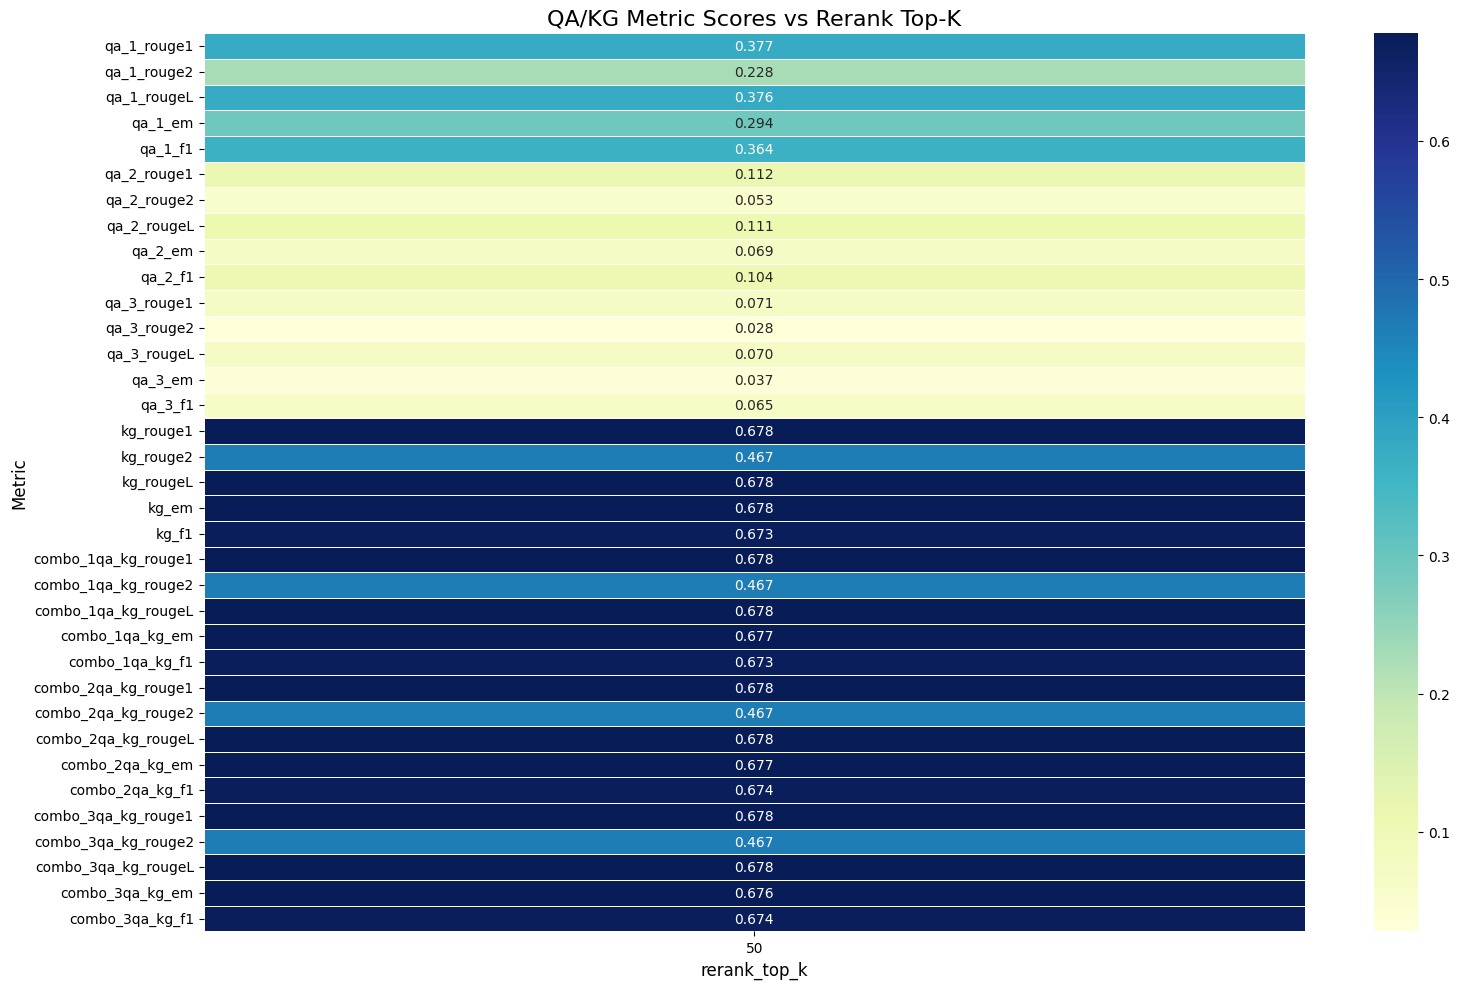

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Run evaluation for different rerank_top_k values
final_result = []
questions = list(questionContext.keys())
Q = questions

rerank_values = [50]

for r in rerank_values:
    print(f"\nEvaluating with rerank_top_k = {r} ...")
    metrics = compute_metrics(Q, questionContext, index, k=300, max_samples=86769, rerank_top_k=r)
    metrics['rerank_top_k'] = r
    final_result.append(metrics)

# 2. Convert to DataFrame
results_df = pd.DataFrame(final_result)

# 3. Transpose and prettify
results_pretty = results_df.set_index("rerank_top_k").T
results_pretty = results_pretty.round(4)

# 4. Display the table
print("\n📊 Evaluation Metrics Table:\n")
print(results_pretty)

# 5. Optional: Save to CSV
results_pretty.to_csv("evaluation_metrics_pretty.csv")

# 6. Optional: Markdown table (for logs or reports)
print("\n📝 Markdown Table:\n")
print(results_pretty.to_markdown())

# 7. Optional: Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(results_pretty, annot=True, cmap="YlGnBu", fmt=".3f", linewidths=0.5)
plt.title("QA/KG Metric Scores vs Rerank Top-K", fontsize=16)
plt.xlabel("rerank_top_k", fontsize=12)
plt.ylabel("Metric", fontsize=12)
plt.tight_layout()
plt.show()


In [20]:
# 86769


📊 Evaluation Metrics Table:

rerank_top_k             50
qa_1_rouge1          0.3767
qa_1_rouge2          0.2280
qa_1_rougeL          0.3762
qa_1_em              0.2944
qa_1_f1              0.3643
qa_2_rouge1          0.1119
qa_2_rouge2          0.0535
qa_2_rougeL          0.1112
qa_2_em              0.0690
qa_2_f1              0.1045
qa_3_rouge1          0.0708
qa_3_rouge2          0.0278
qa_3_rougeL          0.0702
qa_3_em              0.0372
qa_3_f1              0.0650
kg_rouge1            0.6777
kg_rouge2            0.4665
kg_rougeL            0.6777
kg_em                0.6777
kg_f1                0.6733
combo_1qa_kg_rouge1  0.6778
combo_1qa_kg_rouge2  0.4665
combo_1qa_kg_rougeL  0.6778
combo_1qa_kg_em      0.6768
combo_1qa_kg_f1      0.6735
combo_2qa_kg_rouge1  0.6778
combo_2qa_kg_rouge2  0.4665
combo_2qa_kg_rougeL  0.6778
combo_2qa_kg_em      0.6766
combo_2qa_kg_f1      0.6736
combo_3qa_kg_rouge1  0.6778
combo_3qa_kg_rouge2  0.4665
combo_3qa_kg_rougeL  0.6778
combo_3qa_kg_em   

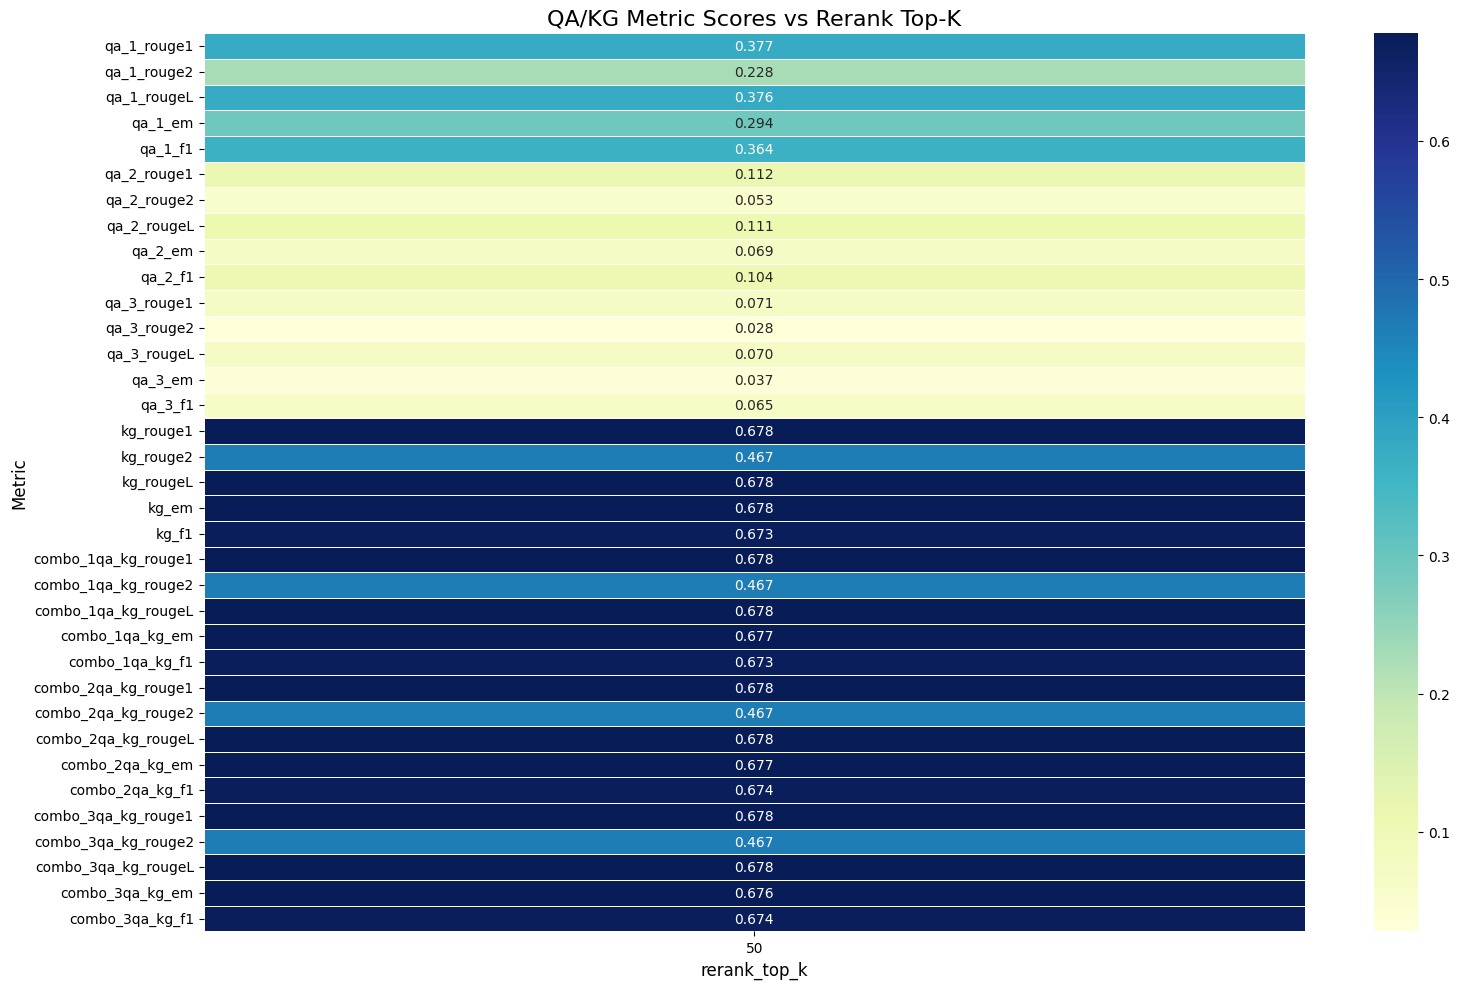

In [21]:
# 2. Convert to DataFrame
results_df = pd.DataFrame(final_result)

# 3. Transpose and prettify
results_pretty = results_df.set_index("rerank_top_k").T
results_pretty = results_pretty.round(4)

# 4. Display the table
print("\n📊 Evaluation Metrics Table:\n")
print(results_pretty)

# 5. Optional: Save to CSV
results_pretty.to_csv("evaluation_metrics_pretty.csv")

# 6. Optional: Markdown table (for logs or reports)
print("\n📝 Markdown Table:\n")
print(results_pretty.to_markdown())

# 7. Optional: Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(results_pretty, annot=True, cmap="YlGnBu", fmt=".3f", linewidths=0.5)
plt.title("QA/KG Metric Scores vs Rerank Top-K", fontsize=16)
plt.xlabel("rerank_top_k", fontsize=12)
plt.ylabel("Metric", fontsize=12)
plt.tight_layout()
plt.show()


In [28]:
def compute_metrics(question, questionContext, index, k, max_samples, rerank_top_k):
    from tqdm import tqdm

    metrics = {
        "qa_1_rouge1": [],
        "qa_1_rouge2": [],
        "qa_1_rougeL": [],
        "qa_1_em": [],
        "qa_1_f1": [],
        "qa_2_rouge1": [],
        "qa_2_rouge2": [],
        "qa_2_rougeL": [],
        "qa_2_em": [],
        "qa_2_f1": [],
        "qa_3_rouge1": [],
        "qa_3_rouge2": [],
        "qa_3_rougeL": [],
        "qa_3_em": [],
        "qa_3_f1": [],
        "kg_rouge1": [],
        "kg_rouge2": [],
        "kg_rougeL": [],
        "kg_em": [],
        "kg_f1": [],
        "combo_1qa_kg_rouge1": [],
        "combo_1qa_kg_rouge2": [],
        "combo_1qa_kg_rougeL": [],
        "combo_1qa_kg_em": [],
        "combo_1qa_kg_f1": [],
        "combo_2qa_kg_rouge1": [],
        "combo_2qa_kg_rouge2": [],
        "combo_2qa_kg_rougeL": [],
        "combo_2qa_kg_em": [],
        "combo_2qa_kg_f1": [],
        "combo_3qa_kg_rouge1": [],
        "combo_3qa_kg_rouge2": [],
        "combo_3qa_kg_rougeL": [],
        "combo_3qa_kg_em": [],
        "combo_3qa_kg_f1": [],
    }

    def score_answer(pred, gold):
        scores = scorer.score(gold, pred)
        rouge1 = scores['rouge1'].fmeasure
        rouge2 = scores['rouge2'].fmeasure
        rougeL = scores['rougeL'].fmeasure
        em = int(pred.strip().lower() == gold.strip().lower())
        pred_tokens = pred.lower().split()
        gold_tokens = gold.lower().split()
        common = set(pred_tokens) & set(gold_tokens)
        if not common:
            f1 = 0.0
        else:
            precision = len(common) / len(pred_tokens)
            recall = len(common) / len(gold_tokens)
            f1 = 2 * precision * recall / (precision + recall)
        return rouge1, rouge2, rougeL, em, f1

    def combine_and_score_best(answers, gold_answer):
        return max((score_answer(ans, gold_answer) for ans in answers), key=lambda x: x[4])  # max by F1

    for idx, ques in enumerate(tqdm(question[:max_samples], desc=f"Evaluating Top-{k}", leave=True, ncols=80)):
        if idx >= max_samples:
            break

        query_vector = vectorizer.transform([ques]).toarray().astype(np.float32)
        faiss.normalize_L2(query_vector)
        distances, indices = index.search(query_vector, k)

        predictions = indices[0]
        actual_index = questionContext[ques]
        actual_ans = data[(data["question"] == ques) & (data["c_id"] == actual_index)]["answer"].iloc[0]

        # Semantic reranking
        top_k_embeddings = np.array([doc_embeddings[i] for i in predictions])
        query_embedding = encode_text([ques])

        top_k_tensor = torch.tensor(top_k_embeddings).float().to(device)
        query_tensor = torch.tensor(query_embedding).float().to(device)
        top_k_tensor = F.normalize(top_k_tensor, p=2, dim=1)
        query_tensor = F.normalize(query_tensor, p=2, dim=1)

        sim_scores = torch.matmul(top_k_tensor, query_tensor.T).squeeze(1)
        reranked_indices = torch.argsort(sim_scores, descending=True).tolist()
        reranked_predictions = [predictions[i] for i in reranked_indices[:rerank_top_k]]

        # Get top 3 QA answers
        qa_answers = []
        for pred_idx in reranked_predictions[:3]:
            context = documents.loc[pred_idx, 'context']
            answer = qa_model(question=ques, context=context)['answer']
            qa_answers.append(answer)

        # Get KG answer
        kg_answer, _ = retrieve_from_kg(ques, question_answer_map)
        enhanced_answer = enhance_kg_answer(ques, kg_answer)
        kg_answer = enhanced_answer

        # QA scores
        r1, r2, rL, em, f1
        for i, ans in enumerate(qa_answers):
            r1, r2, rL, em, f1 = score_answer(ans, actual_ans)
            
            metrics[f"qa_{i+1}_rouge1"].append(r1)
            metrics[f"qa_{i+1}_rouge2"].append(r2)
            metrics[f"qa_{i+1}_rougeL"].append(rL)
            metrics[f"qa_{i+1}_em"].append(em)
            metrics[f"qa_{i+1}_f1"].append(f1)

        # KG scores
        r1, r2, rL, em, f1 = score_answer(kg_answer, actual_ans)
        metrics["kg_rouge1"].append(r1)
        metrics["kg_rouge2"].append(r2)
        metrics["kg_rougeL"].append(rL)
        metrics["kg_em"].append(em)
        metrics["kg_f1"].append(f1)

        # Combo scores (best of QA and KG)
        r1, r2, rL, em, f1 = combine_and_score_best([qa_answers[0], kg_answer], actual_ans)
        metrics["combo_1qa_kg_rouge1"].append(r1)
        metrics["combo_1qa_kg_rouge2"].append(r2)
        metrics["combo_1qa_kg_rougeL"].append(rL)
        metrics["combo_1qa_kg_em"].append(em)
        metrics["combo_1qa_kg_f1"].append(f1)

        r1, r2, rL, em, f1 = combine_and_score_best(qa_answers[:2] + [kg_answer], actual_ans)
        metrics["combo_2qa_kg_rouge1"].append(r1)
        metrics["combo_2qa_kg_rouge2"].append(r2)
        metrics["combo_2qa_kg_rougeL"].append(rL)
        metrics["combo_2qa_kg_em"].append(em)
        metrics["combo_2qa_kg_f1"].append(f1)

        r1, r2, rL, em, f1 = combine_and_score_best(qa_answers[:3] + [kg_answer], actual_ans)
        metrics["combo_3qa_kg_rouge1"].append(r1)
        metrics["combo_3qa_kg_rouge2"].append(r2)
        metrics["combo_3qa_kg_rougeL"].append(rL)
        metrics["combo_3qa_kg_em"].append(em)
        metrics["combo_3qa_kg_f1"].append(f1)

    return {key: np.mean(val) for key, val in metrics.items()}



Evaluating with rerank_top_k = 50 ...


Evaluating Top-300: 100%|███████████████████| 2000/2000 [07:50<00:00,  4.25it/s]



📊 Evaluation Metrics Table:

rerank_top_k             50
qa_1_rouge1          0.5691
qa_1_rouge2          0.3358
qa_1_rougeL          0.5688
qa_1_em              0.4690
qa_1_f1              0.5475
qa_2_rouge1          0.1729
qa_2_rouge2          0.0849
qa_2_rougeL          0.1728
qa_2_em              0.1180
qa_2_f1              0.1654
qa_3_rouge1          0.1092
qa_3_rouge2          0.0412
qa_3_rougeL          0.1088
qa_3_em              0.0695
qa_3_f1              0.1021
kg_rouge1            0.2283
kg_rouge2            0.0458
kg_rougeL            0.2274
kg_em                0.1380
kg_f1                0.2067
combo_1qa_kg_rouge1  0.6534
combo_1qa_kg_rouge2  0.3569
combo_1qa_kg_rougeL  0.6528
combo_1qa_kg_em      0.5300
combo_1qa_kg_f1      0.6324
combo_2qa_kg_rouge1  0.7329
combo_2qa_kg_rouge2  0.4155
combo_2qa_kg_rougeL  0.7323
combo_2qa_kg_em      0.6035
combo_2qa_kg_f1      0.7127
combo_3qa_kg_rouge1  0.7654
combo_3qa_kg_rouge2  0.4420
combo_3qa_kg_rougeL  0.7648
combo_3qa_kg_em   

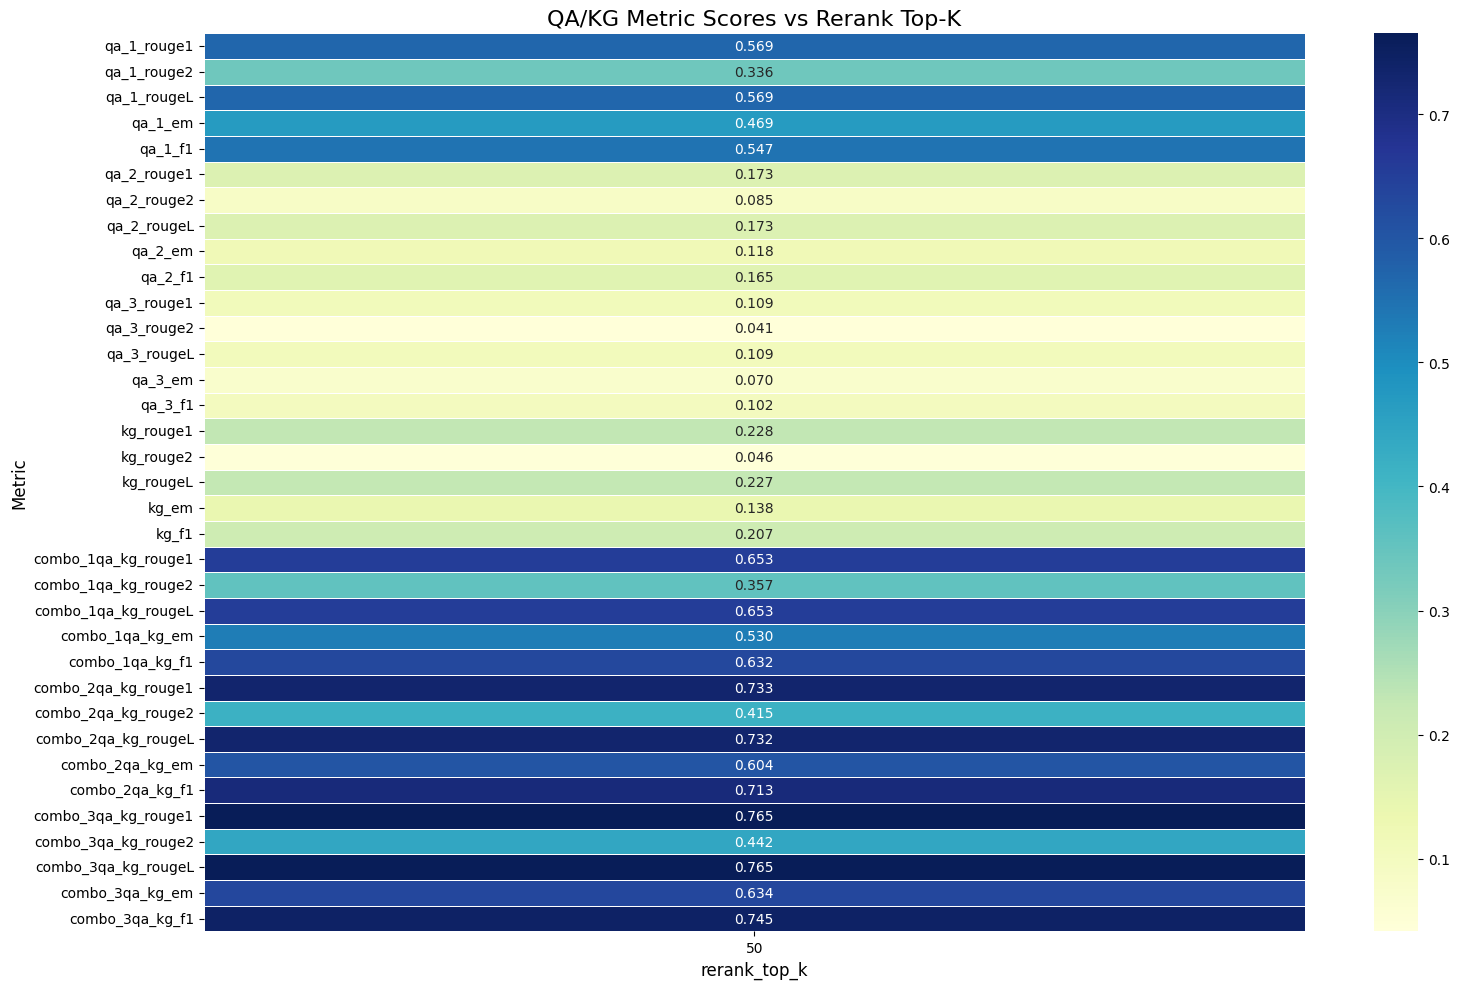

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Run evaluation for different rerank_top_k values
final_result = []
questions = list(questionContext.keys())
Q = questions

rerank_values = [50]

for r in rerank_values:
    print(f"\nEvaluating with rerank_top_k = {r} ...")
    metrics = compute_metrics(Q, questionContext, index, k=300, max_samples=2000, rerank_top_k=r)
    metrics['rerank_top_k'] = r
    final_result.append(metrics)

# 2. Convert to DataFrame
results_df = pd.DataFrame(final_result)

# 3. Transpose and prettify
results_pretty = results_df.set_index("rerank_top_k").T
results_pretty = results_pretty.round(4)

# 4. Display the table
print("\n📊 Evaluation Metrics Table:\n")
print(results_pretty)

# 5. Optional: Save to CSV
results_pretty.to_csv("evaluation_metrics_pretty.csv")

# 6. Optional: Markdown table (for logs or reports)
print("\n📝 Markdown Table:\n")
print(results_pretty.to_markdown())

# 7. Optional: Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(results_pretty, annot=True, cmap="YlGnBu", fmt=".3f", linewidths=0.5)
plt.title("QA/KG Metric Scores vs Rerank Top-K", fontsize=16)
plt.xlabel("rerank_top_k", fontsize=12)
plt.ylabel("Metric", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# 2. Convert to DataFrame
results_df = pd.DataFrame(final_result)

# 3. Transpose and prettify
results_pretty = results_df.set_index("rerank_top_k").T
results_pretty = results_pretty.round(4)

# 4. Display the table
print("\n📊 Evaluation Metrics Table:\n")
print(results_pretty)

# 5. Optional: Save to CSV
results_pretty.to_csv("evaluation_metrics_pretty.csv")

# 6. Optional: Markdown table (for logs or reports)
print("\n📝 Markdown Table:\n")
print(results_pretty.to_markdown())

# 7. Optional: Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(results_pretty, annot=True, cmap="YlGnBu", fmt=".3f", linewidths=0.5)
plt.title("QA/KG Metric Scores vs Rerank Top-K", fontsize=16)
plt.xlabel("rerank_top_k", fontsize=12)
plt.ylabel("Metric", fontsize=12)
plt.tight_layout()
plt.show()


In [35]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
import torch.nn.functional as F

metric_names = ["rouge1", "rouge2", "rougeL", "em", "f1"]

def score_answer(pred, gold):
    scores = scorer.score(gold, pred)
    rouge1 = scores['rouge1'].fmeasure
    rouge2 = scores['rouge2'].fmeasure
    rougeL = scores['rougeL'].fmeasure
    em = int(pred.strip().lower() == gold.strip().lower())

    pred_tokens = pred.lower().split()
    gold_tokens = gold.lower().split()
    common = set(pred_tokens) & set(gold_tokens)
    if not common:
        f1 = 0.0
    else:
        precision = len(common) / len(pred_tokens)
        recall = len(common) / len(gold_tokens)
        f1 = 2 * precision * recall / (precision + recall)
    return rouge1, rouge2, rougeL, em, f1

def compute_metrics(question, questionContext, index, k, max_samples, rerank_top_k):
    qa_max_scores = []
    kg_scores = []
    best_of_all_scores = []

    for idx in tqdm(range(min(len(question), max_samples)), desc=f"Evaluating Top-{k}", leave=True, ncols=80):
        ques = question[idx]

        # Vector search
        query_vector = vectorizer.transform([ques]).toarray().astype(np.float32)
        faiss.normalize_L2(query_vector)
        distances, indices = index.search(query_vector, k)
        predictions = indices[0]

        # Ground truth
        actual_index = questionContext[ques]
        try:
            actual_ans = data.loc[(data["question"] == ques) & (data["c_id"] == actual_index), "answer"].values[0]
        except IndexError:
            continue  # Skip if ground truth not found

        # Semantic rerank
        top_k_embeddings = np.array([doc_embeddings[i] for i in predictions])
        query_embedding = encode_text([ques])
        top_k_tensor = torch.tensor(top_k_embeddings).float().to(device)
        query_tensor = torch.tensor(query_embedding).float().to(device)
        top_k_tensor = F.normalize(top_k_tensor, p=2, dim=1)
        query_tensor = F.normalize(query_tensor, p=2, dim=1)
        sim_scores = torch.matmul(top_k_tensor, query_tensor.T).squeeze(1)
        reranked_indices = torch.argsort(sim_scores, descending=True).tolist()
        reranked_predictions = [predictions[i] for i in reranked_indices[:10]]

        # QA answers (top 10 by relevance → top 3 by score)
        qa_scores = []
        for pred_idx in reranked_predictions:
            context = documents.loc[pred_idx, 'context']
            output = qa_model(question=ques, context=context)
            answer = output['answer']
            score = output.get('score', 0)
            qa_scores.append((score, answer))

        qa_scores.sort(reverse=True, key=lambda x: x[0])
        qa_top3_answers = [x[1] for x in qa_scores[:3]]
        qa_metric_scores = [score_answer(ans, actual_ans) for ans in qa_top3_answers]

        # Max of QA
        qa_max = np.stack(qa_metric_scores).max(axis=0)
        qa_max_scores.append(qa_max)

        # KG
        kg_answer, _ = retrieve_from_kg(ques, question_answer_map)
        kg_answer = enhance_kg_answer(ques, kg_answer)
        kg_metric_score = score_answer(kg_answer, actual_ans)
        kg_scores.append(kg_metric_score)

        # Best among all 4 (3 QA + 1 KG)
        all_scores = qa_metric_scores + [kg_metric_score]
        best_all = np.stack(all_scores).max(axis=0)
        best_of_all_scores.append(best_all)

    return {
        "qa_max": pd.DataFrame(qa_max_scores, columns=metric_names),
        "kg_only": pd.DataFrame(kg_scores, columns=metric_names),
        "best_all": pd.DataFrame(best_of_all_scores, columns=metric_names)
    }

# === Run Script ===
questions = list(questionContext.keys())
rerank_values = [50]
final_result = []

for r in rerank_values:
    print(f"\nEvaluating with rerank_top_k = {r} ...")
    result = compute_metrics(
        question=questions,
        questionContext=questionContext,
        index=index,
        k=300,
        max_samples=2000,
        rerank_top_k=r
    )
    result["rerank_top_k"] = r
    final_result.append(result)


# 2. Convert to DataFrame
results_df = pd.DataFrame(final_result)

# 3. Transpose and prettify
results_pretty = results_df.set_index("rerank_top_k").T
results_pretty = results_pretty.round(4)

# 4. Display the table
print("\n📊 Evaluation Metrics Table:\n")
print(results_pretty)

# 5. Optional: Save to CSV
results_pretty.to_csv("evaluation_metrics_pretty.csv")

# 6. Optional: Markdown table (for logs or reports)
print("\n📝 Markdown Table:\n")
print(results_pretty.to_markdown())

# 7. Optional: Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(results_pretty, annot=True, cmap="YlGnBu", fmt=".3f", linewidths=0.5)
plt.title("QA/KG Metric Scores vs Rerank Top-K", fontsize=16)
plt.xlabel("rerank_top_k", fontsize=12)
plt.ylabel("Metric", fontsize=12)
plt.tight_layout()
plt.show()



Evaluating with rerank_top_k = 50 ...


Evaluating Top-300: 100%|███████████████████| 2000/2000 [10:57<00:00,  3.04it/s]


📊 Evaluation Metrics Table:

rerank_top_k                                                 50
qa_max                rouge1  rouge2    rougeL   em        f...
kg_only               rouge1  rouge2    rougeL  em        f1...
best_all              rouge1  rouge2    rougeL   em        f...

📝 Markdown Table:



ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [36]:
print(final_result)

[{'qa_max':         rouge1  rouge2    rougeL   em        f1
0     0.000000     0.0  0.000000  0.0  0.000000
1     0.000000     0.0  0.000000  0.0  0.000000
2     1.000000     0.0  1.000000  1.0  1.000000
3     0.000000     0.0  0.000000  0.0  0.000000
4     0.000000     0.0  0.000000  0.0  0.000000
...        ...     ...       ...  ...       ...
1995  0.666667     0.0  0.666667  0.0  0.666667
1996  1.000000     0.0  1.000000  1.0  1.000000
1997  1.000000     1.0  1.000000  1.0  1.000000
1998  1.000000     0.0  1.000000  1.0  1.000000
1999  0.000000     0.0  0.000000  0.0  0.000000

[2000 rows x 5 columns], 'kg_only':         rouge1  rouge2    rougeL  em        f1
0     0.400000     0.0  0.400000   0  0.400000
1     0.000000     0.0  0.000000   0  0.000000
2     1.000000     0.0  1.000000   1  1.000000
3     0.666667     0.0  0.666667   0  0.666667
4     0.666667     0.0  0.666667   0  0.666667
...        ...     ...       ...  ..       ...
1995  0.000000     0.0  0.000000   0  0.000000

In [37]:
qa_df = final_result[0]['qa_max']
kg_df = final_result[0]['kg_only']
best_df = final_result[0]['best_all']

In [38]:
print(qa_df)

        rouge1  rouge2    rougeL   em        f1
0     0.000000     0.0  0.000000  0.0  0.000000
1     0.000000     0.0  0.000000  0.0  0.000000
2     1.000000     0.0  1.000000  1.0  1.000000
3     0.000000     0.0  0.000000  0.0  0.000000
4     0.000000     0.0  0.000000  0.0  0.000000
...        ...     ...       ...  ...       ...
1995  0.666667     0.0  0.666667  0.0  0.666667
1996  1.000000     0.0  1.000000  1.0  1.000000
1997  1.000000     1.0  1.000000  1.0  1.000000
1998  1.000000     0.0  1.000000  1.0  1.000000
1999  0.000000     0.0  0.000000  0.0  0.000000

[2000 rows x 5 columns]


In [39]:
for res in final_result:
    r = res['rerank_top_k']
    qa = res['qa_max'].mean().to_dict()
    kg = res['kg_only'].mean().to_dict()
    best = res['best_all'].mean().to_dict()

    print(f"\n📊 Rerank Top K = {r}")
    print("QA Max Avg:", qa)
    print("KG Only Avg:", kg)
    print("Best of All Avg:", best)


📊 Rerank Top K = 50
QA Max Avg: {'rouge1': 0.7764397224163865, 'rouge2': 0.4690870792434259, 'rougeL': 0.776306389083053, 'em': 0.655, 'f1': 0.7527521592356732}
KG Only Avg: {'rouge1': 0.2283382548136418, 'rouge2': 0.04575932090785032, 'rougeL': 0.22737992148030847, 'em': 0.138, 'f1': 0.20668170161022328}
Best of All Avg: {'rouge1': 0.8199222623180054, 'rouge2': 0.48472060650048265, 'rougeL': 0.8195472623180053, 'em': 0.6845, 'f1': 0.7913428588954905}


In [40]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
import torch.nn.functional as F

metric_names = ["rouge1", "rouge2", "rougeL", "em", "f1"]

def score_answer(pred, gold):
    scores = scorer.score(gold, pred)
    rouge1 = scores['rouge1'].fmeasure
    rouge2 = scores['rouge2'].fmeasure
    rougeL = scores['rougeL'].fmeasure
    em = int(pred.strip().lower() == gold.strip().lower())

    pred_tokens = pred.lower().split()
    gold_tokens = gold.lower().split()
    common = set(pred_tokens) & set(gold_tokens)
    if not common:
        f1 = 0.0
    else:
        precision = len(common) / len(pred_tokens)
        recall = len(common) / len(gold_tokens)
        f1 = 2 * precision * recall / (precision + recall)
    return rouge1, rouge2, rougeL, em, f1

def compute_metrics(question, questionContext, index, k, max_samples, rerank_top_k):
    qa_max_scores = []
    kg_scores = []
    best_of_all_scores = []

    for idx in tqdm(range(min(len(question), max_samples)), desc=f"Evaluating Top-{k}", leave=True, ncols=80):
        ques = question[idx]

        # Vector search
        query_vector = vectorizer.transform([ques]).toarray().astype(np.float32)
        faiss.normalize_L2(query_vector)
        distances, indices = index.search(query_vector, k)
        predictions = indices[0]

        # Ground truth
        actual_index = questionContext[ques]
        try:
            actual_ans = data.loc[(data["question"] == ques) & (data["c_id"] == actual_index), "answer"].values[0]
        except IndexError:
            continue  # Skip if ground truth not found

        # Semantic rerank
        top_k_embeddings = np.array([doc_embeddings[i] for i in predictions])
        query_embedding = encode_text([ques])
        top_k_tensor = torch.tensor(top_k_embeddings).float().to(device)
        query_tensor = torch.tensor(query_embedding).float().to(device)
        top_k_tensor = F.normalize(top_k_tensor, p=2, dim=1)
        query_tensor = F.normalize(query_tensor, p=2, dim=1)
        sim_scores = torch.matmul(top_k_tensor, query_tensor.T).squeeze(1)
        reranked_indices = torch.argsort(sim_scores, descending=True).tolist()
        reranked_predictions = [predictions[i] for i in reranked_indices[:10]]

        # QA answers (top 10 by relevance → top 3 by score)
        qa_scores = []
        for pred_idx in reranked_predictions:
            context = documents.loc[pred_idx, 'context']
            output = qa_model(question=ques, context=context)
            answer = output['answer']
            score = output.get('score', 0)
            qa_scores.append((score, answer))

        qa_scores.sort(reverse=True, key=lambda x: x[0])
        qa_top3_answers = [x[1] for x in qa_scores[:3]]
        qa_metric_scores = [score_answer(ans, actual_ans) for ans in qa_top3_answers]

        # Max of QA
        qa_max = np.stack(qa_metric_scores).max(axis=0)
        qa_max_scores.append(qa_max)

        # KG
        kg_answer, _ = retrieve_from_kg(ques, question_answer_map)
        # kg_answer = enhance_kg_answer(ques, kg_answer)
        kg_metric_score = score_answer(kg_answer, actual_ans)
        kg_scores.append(kg_metric_score)

        # Best among all 4 (3 QA + 1 KG)
        all_scores = qa_metric_scores + [kg_metric_score]
        best_all = np.stack(all_scores).max(axis=0)
        best_of_all_scores.append(best_all)

    return {
        "qa_max": pd.DataFrame(qa_max_scores, columns=metric_names),
        "kg_only": pd.DataFrame(kg_scores, columns=metric_names),
        "best_all": pd.DataFrame(best_of_all_scores, columns=metric_names)
    }

# === Run Script ===
questions = list(questionContext.keys())
rerank_values = [50]
final_result = []

for r in rerank_values:
    print(f"\nEvaluating with rerank_top_k = {r} ...")
    result = compute_metrics(
        question=questions,
        questionContext=questionContext,
        index=index,
        k=300,
        max_samples=2000,
        rerank_top_k=r
    )
    result["rerank_top_k"] = r
    final_result.append(result)


Evaluating with rerank_top_k = 50 ...


Evaluating Top-300: 100%|███████████████████| 2000/2000 [06:23<00:00,  5.22it/s]


In [41]:
for res in final_result:
    r = res['rerank_top_k']
    qa = res['qa_max'].mean().to_dict()
    kg = res['kg_only'].mean().to_dict()
    best = res['best_all'].mean().to_dict()

    print(f"\n📊 Rerank Top K = {r}")
    print("QA Max Avg:", qa)
    print("KG Only Avg:", kg)
    print("Best of All Avg:", best)


📊 Rerank Top K = 50
QA Max Avg: {'rouge1': 0.7764397224163865, 'rouge2': 0.4690870792434259, 'rougeL': 0.776306389083053, 'em': 0.655, 'f1': 0.7527521592356732}
KG Only Avg: {'rouge1': 0.9996136363636364, 'rouge2': 0.6703333333333332, 'rougeL': 0.9996136363636364, 'em': 0.9985, 'f1': 0.9974861485736486}
Best of All Avg: {'rouge1': 0.9996136363636364, 'rouge2': 0.6703333333333332, 'rougeL': 0.9996136363636364, 'em': 0.9985, 'f1': 0.9975098327841749}


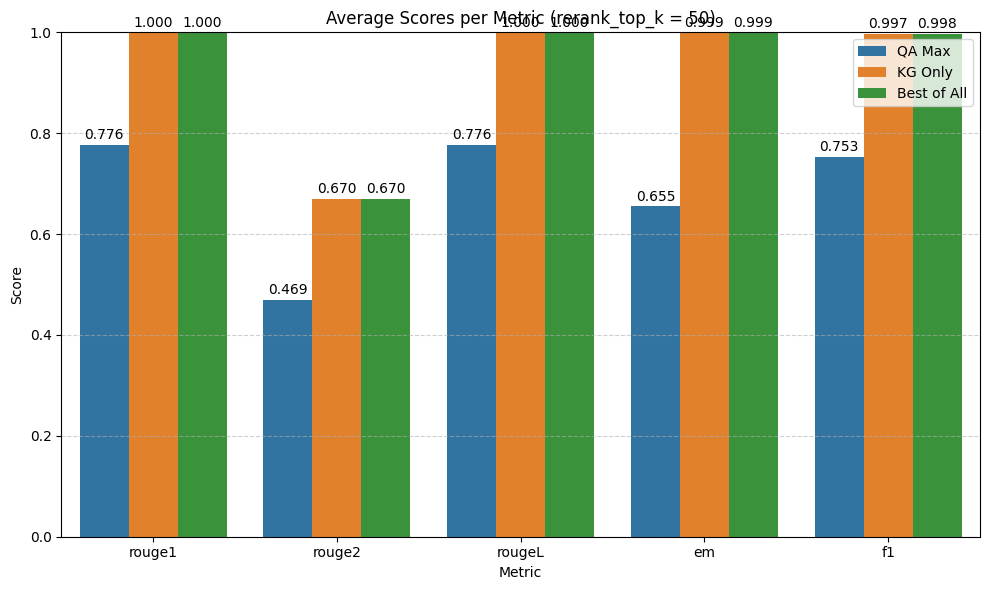

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Collect average scores for each metric/system
bar_data = []

for res in final_result:
    r = res["rerank_top_k"]
    qa_avg = res["qa_max"].mean()
    kg_avg = res["kg_only"].mean()
    best_avg = res["best_all"].mean()

    for metric in ["rouge1", "rouge2", "rougeL", "em", "f1"]:
        bar_data.append({
            "Metric": metric,
            "Score": qa_avg[metric],
            "System": "QA Max",
            "rerank_top_k": r
        })
        bar_data.append({
            "Metric": metric,
            "Score": kg_avg[metric],
            "System": "KG Only",
            "rerank_top_k": r
        })
        bar_data.append({
            "Metric": metric,
            "Score": best_avg[metric],
            "System": "Best of All",
            "rerank_top_k": r
        })

# Step 2: Create DataFrame
df_bar = pd.DataFrame(bar_data)

# Step 3: Plot grouped bar chart with annotations
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_bar,
    x="Metric",
    y="Score",
    hue="System"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", padding=2)

# Finalize plot
plt.title(f"Average Scores per Metric (rerank_top_k = {final_result[0]['rerank_top_k']})")
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend(loc='upper right')
plt.show()


In [45]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
import torch.nn.functional as F

metric_names = ["rouge1", "rouge2", "rougeL", "em", "f1"]

def score_answer(pred, gold):
    scores = scorer.score(gold, pred)
    rouge1 = scores['rouge1'].fmeasure
    rouge2 = scores['rouge2'].fmeasure
    rougeL = scores['rougeL'].fmeasure
    em = int(pred.strip().lower() == gold.strip().lower())

    pred_tokens = pred.lower().split()
    gold_tokens = gold.lower().split()
    common = set(pred_tokens) & set(gold_tokens)
    if not common:
        f1 = 0.0
    else:
        precision = len(common) / len(pred_tokens)
        recall = len(common) / len(gold_tokens)
        f1 = 2 * precision * recall / (precision + recall)
    return rouge1, rouge2, rougeL, em, f1

def compute_metrics(question, questionContext, index, k, max_samples, rerank_top_k):
    qa_max_scores = []
    kg_scores = []
    best_of_all_scores = []

    for idx in tqdm(range(min(len(question), max_samples)), desc=f"Evaluating Top-{k}", leave=True, ncols=80):
        ques = question[idx]

        # Vector search
        query_vector = vectorizer.transform([ques]).toarray().astype(np.float32)
        faiss.normalize_L2(query_vector)
        distances, indices = index.search(query_vector, k)
        predictions = indices[0]

        # Ground truth
        actual_index = questionContext[ques]
        try:
            actual_ans = data.loc[(data["question"] == ques) & (data["c_id"] == actual_index), "answer"].values[0]
        except IndexError:
            continue  # Skip if ground truth not found

        # Semantic rerank
        top_k_embeddings = np.array([doc_embeddings[i] for i in predictions])
        query_embedding = encode_text([ques])
        top_k_tensor = torch.tensor(top_k_embeddings).float().to(device)
        query_tensor = torch.tensor(query_embedding).float().to(device)
        top_k_tensor = F.normalize(top_k_tensor, p=2, dim=1)
        query_tensor = F.normalize(query_tensor, p=2, dim=1)
        sim_scores = torch.matmul(top_k_tensor, query_tensor.T).squeeze(1)
        reranked_indices = torch.argsort(sim_scores, descending=True).tolist()
        reranked_predictions = [predictions[i] for i in reranked_indices[:10]]

        # QA answers (top 10 by relevance → top 3 by score)
        qa_scores = []
        for pred_idx in reranked_predictions:
            context = documents.loc[pred_idx, 'context']
            output = qa_model(question=ques, context=context)
            answer = output['answer']
            score = output.get('score', 0)
            qa_scores.append((score, answer))

        qa_scores.sort(reverse=True, key=lambda x: x[0])
        qa_top3_answers = [x[1] for x in qa_scores[:3]]
        qa_metric_scores = [score_answer(ans, actual_ans) for ans in qa_top3_answers]

        # Max of QA
        qa_max = np.stack(qa_metric_scores).max(axis=0)
        qa_max_scores.append(qa_max)

        # KG
        kg_answer, _ = retrieve_from_kg(ques, question_answer_map)
        # kg_answer = enhance_kg_answer(ques, kg_answer)
        kg_metric_score = score_answer(kg_answer, actual_ans)
        kg_scores.append(kg_metric_score)

        # Best among all 4 (3 QA + 1 KG)
        all_scores = qa_metric_scores + [kg_metric_score]
        best_all = np.stack(all_scores).max(axis=0)
        best_of_all_scores.append(best_all)

    return {
        "qa_max": pd.DataFrame(qa_max_scores, columns=metric_names),
        "kg_only": pd.DataFrame(kg_scores, columns=metric_names),
        "best_all": pd.DataFrame(best_of_all_scores, columns=metric_names)
    }

# === Run Script ===
questions = list(questionContext.keys())
rerank_values = [50]
final_result = []

for r in rerank_values:
    print(f"\nEvaluating with rerank_top_k = {r} ...")
    result = compute_metrics(
        question=questions,
        questionContext=questionContext,
        index=index,
        k=300,
        max_samples=20000,
        rerank_top_k=r
    )
    result["rerank_top_k"] = r
    final_result.append(result)


Evaluating with rerank_top_k = 50 ...


Evaluating Top-300: 100%|███████████████| 20000/20000 [1:00:53<00:00,  5.47it/s]


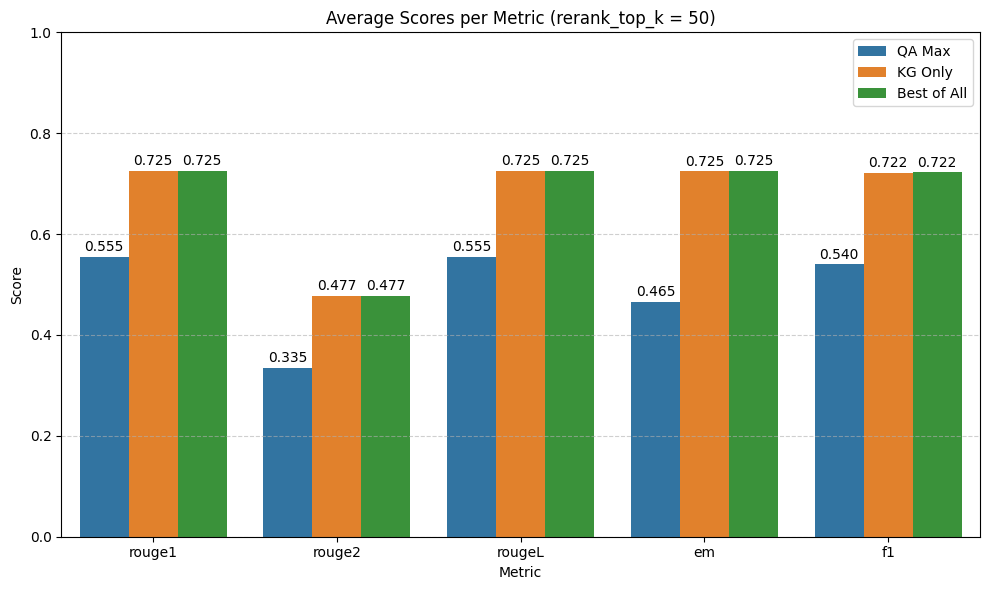

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Collect average scores for each metric/system
bar_data = []

for res in final_result:
    r = res["rerank_top_k"]
    qa_avg = res["qa_max"].mean()
    kg_avg = res["kg_only"].mean()
    best_avg = res["best_all"].mean()

    for metric in ["rouge1", "rouge2", "rougeL", "em", "f1"]:
        bar_data.append({
            "Metric": metric,
            "Score": qa_avg[metric],
            "System": "QA Max",
            "rerank_top_k": r
        })
        bar_data.append({
            "Metric": metric,
            "Score": kg_avg[metric],
            "System": "KG Only",
            "rerank_top_k": r
        })
        bar_data.append({
            "Metric": metric,
            "Score": best_avg[metric],
            "System": "Best of All",
            "rerank_top_k": r
        })

# Step 2: Create DataFrame
df_bar = pd.DataFrame(bar_data)

# Step 3: Plot grouped bar chart with annotations
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_bar,
    x="Metric",
    y="Score",
    hue="System"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", padding=2)

# Finalize plot
plt.title(f"Average Scores per Metric (rerank_top_k = {final_result[0]['rerank_top_k']})")
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend(loc='upper right')
plt.show()